In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dims = [2, 4, 8, 16, 32, 64, 128]
n_points = 1000
delta_0 = []
delta_1 = []

In [3]:
for d in dims:
    X = np.random.uniform(-1, 1, size=(n_points, d))
    distances = np.linalg.norm(X, axis=1)
    
    delta_0.append(np.min(distances))
    delta_1.append(np.max(distances))

delta_0 = np.array(delta_0)
delta_1 = np.array(delta_1)

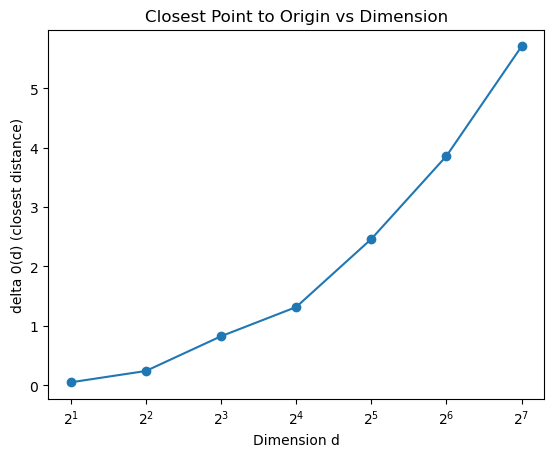

In [6]:
plt.figure()
plt.plot(dims, delta_0, marker='o')
plt.xlabel("Dimension d")
plt.ylabel("delta 0(d) (closest distance)")
plt.title("Closest Point to Origin vs Dimension")
plt.xscale('log', base=2)
plt.show()

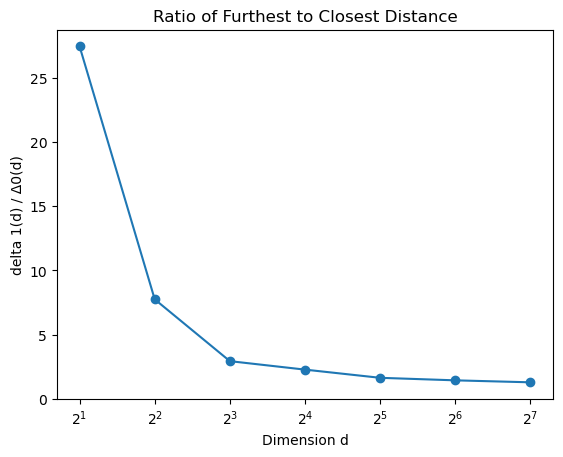

In [7]:
ratio = delta_1 / delta_0

plt.figure()
plt.plot(dims, ratio, marker='o')
plt.xlabel("Dimension d")
plt.ylabel("delta 1(d) / Δ0(d)")
plt.title("Ratio of Furthest to Closest Distance")
plt.xscale('log', base=2)
plt.show()

In [ ]:

data = np.load('/Users/k_anisha/Library/CloudStorage/OneDrive-Personal/UCSD/YEAR 2/SPRING 2026/DSC 140A/mnist.npz')

In [ ]:
# makes it into the correct shape for knn_predict
X_train = data['train'].T
X_test = data['test'].T

X_train = X_train.astype(np.int16)
X_test = X_test.astype(np.int16)

y_train = data['train_labels'].astype(int)
y_test = data['test_labels'].astype(int)

def knn_predict(X_train, y_train, x, k=1): # function from de lecture
    distances = np.linalg.norm(X_train - x, axis = 1)
    nearest = np.argpartition(distances, k)[:k]
    nearest_labels = y_train[nearest]
    return np.bincount(nearest_labels).argmax()

In [ ]:
#idk if this is right :(

correct = 0
predictions = []

for i in range(100):
    pred = knn_predict(X_train, y_train, X_test[i], k=1)
    predictions.append(pred)
    if pred == y_test[i]:
        correct += 1

accuracy = correct / 100
print("Accuracy:", accuracy)

p0 = knn_predict(X_train, y_train, X_test[0], k=1)
p500 = knn_predict(X_train, y_train, X_test[500], k=1)
p1000 = knn_predict(X_train, y_train, X_test[1000], k=1)

print("Predictions:", p0, p500, p1000)

Accuracy: 0.98
Predictions: 3 3 3


In [ ]:
"""
A short list of the changes I had to make:
- I transposed the trianing and test arrays 
- I converted from uint8 to int16, which fixes the 'wraparound' issue
- I converted the labels to integers
"""